# Road Segmentation — Test & Visualisation
Runs `segment_roads.py` and plots the output.

In [1]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'TH Sarabun New'

import subprocess, sys
result = subprocess.run(
    [sys.executable, "../src/geospatial/spatial/segment_roads.py"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)


Traceback (most recent call last):
  File "/Users/biocorn/Documents/GitHub/H-Spot/notebooks/../src/geospatial/spatial/segment_roads.py", line 125, in <module>
    main()
  File "/Users/biocorn/Documents/GitHub/H-Spot/notebooks/../src/geospatial/spatial/segment_roads.py", line 74, in main
    cfg = load_config()
          ^^^^^^^^^^^^^
  File "/Users/biocorn/Documents/GitHub/H-Spot/notebooks/../src/geospatial/spatial/segment_roads.py", line 24, in load_config
    with open(path) as f:
         ^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'configs/data_sources.yaml'



In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

segments     = gpd.read_file("../data/processed/road_segments.gpkg")
intersections = gpd.read_file("../data/processed/intersections.gpkg")

print(f"Segments     : {len(segments):,}")
print(f"Intersections: {len(intersections):,}")
print()
print(segments[["segment_id","highway","name","length_m"]].head())

Segments     : 276,062
Intersections: 11,259

   segment_id       highway           name  length_m
0           0  unclassified  ถนนลัดคลองตัน     100.0
1           1  unclassified  ถนนลัดคลองตัน     100.0
2           2  unclassified  ถนนลัดคลองตัน     100.0
3           3  unclassified  ถนนลัดคลองตัน     100.0
4           4  unclassified  ถนนลัดคลองตัน     100.0


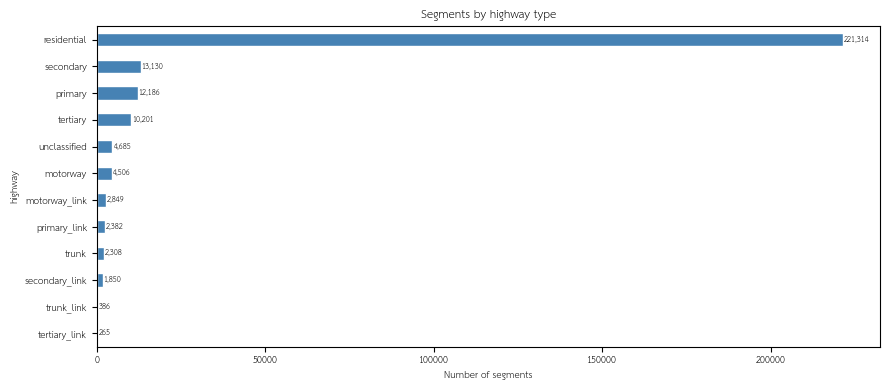

In [3]:
# --- Highway type distribution ---
fig, ax = plt.subplots(figsize=(9, 4))
counts = segments["highway"].value_counts()
counts.plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Number of segments")
ax.set_title("Segments by highway type")
ax.invert_yaxis()
for bar, val in zip(ax.patches, counts):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

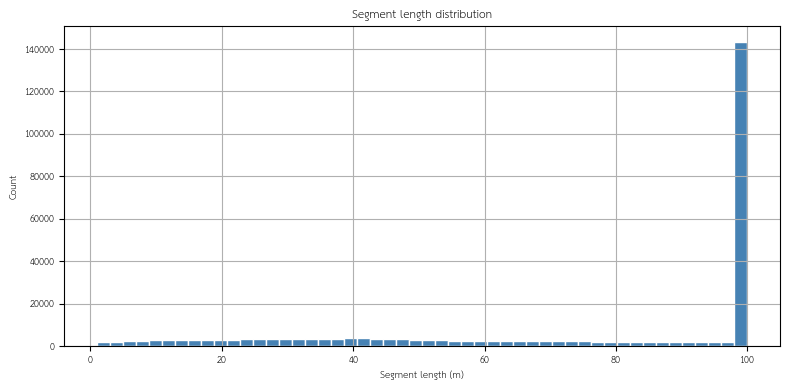

count    276062.000000
mean         74.098846
std          32.392310
min           1.000000
25%          45.110000
50%         100.000000
75%         100.000000
max         100.000000
Name: length_m, dtype: float64


In [4]:
# --- Segment length distribution ---
fig, ax = plt.subplots(figsize=(8, 4))
segments["length_m"].hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Segment length (m)")
ax.set_ylabel("Count")
ax.set_title("Segment length distribution")
plt.tight_layout()
plt.show()
print(segments["length_m"].describe())

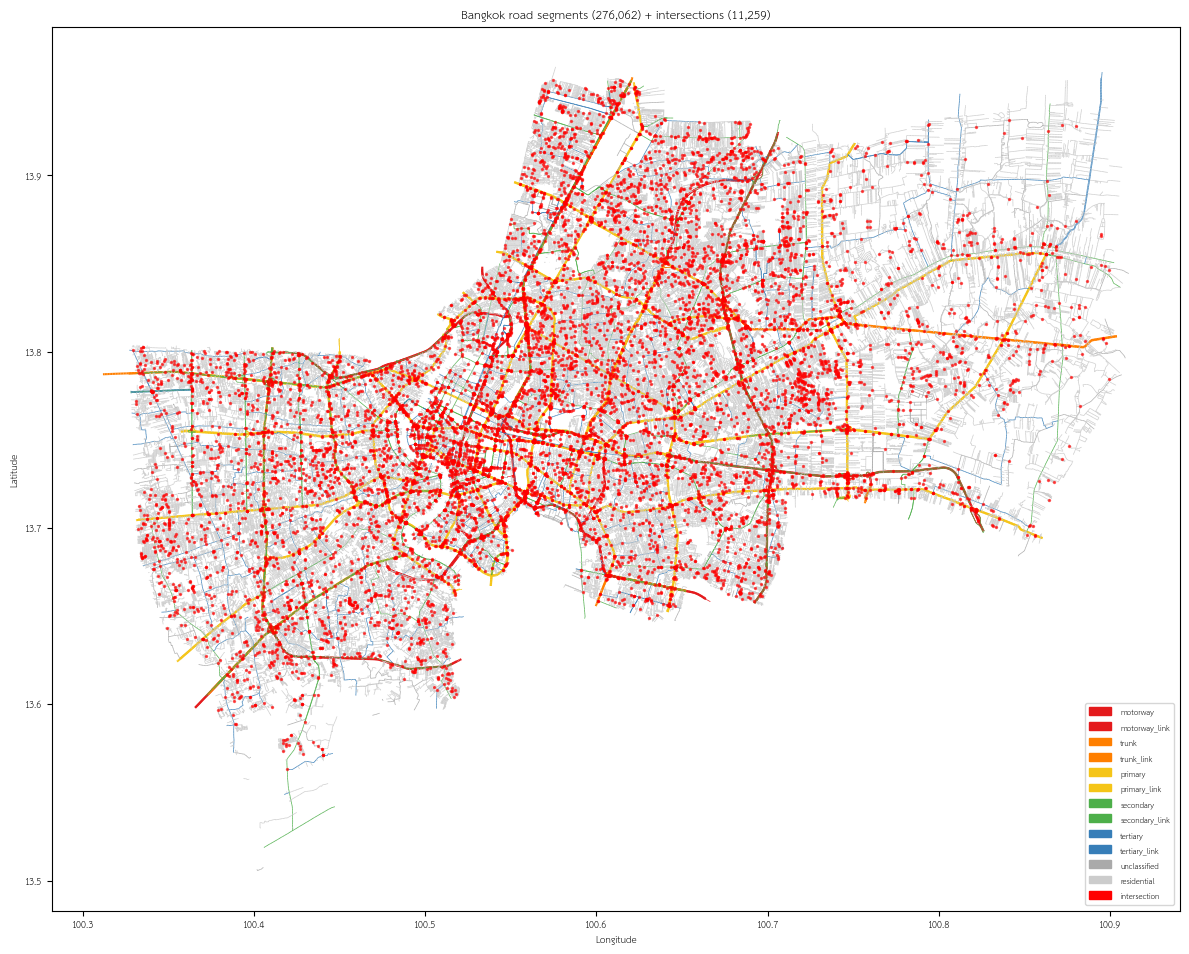

In [5]:
# --- Full Bangkok map: segments coloured by highway type + intersections ---
HIGHWAY_COLORS = {
    "motorway":       "#e41a1c",
    "motorway_link":  "#e41a1c",
    "trunk":          "#ff7f00",
    "trunk_link":     "#ff7f00",
    "primary":        "#f5c518",
    "primary_link":   "#f5c518",
    "secondary":      "#4daf4a",
    "secondary_link": "#4daf4a",
    "tertiary":       "#377eb8",
    "tertiary_link":  "#377eb8",
    "unclassified":   "#aaaaaa",
    "residential":    "#cccccc",
}

# reproject to WGS84 for display
segs_wgs  = segments.to_crs("EPSG:4326")
ints_wgs  = intersections.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(12, 12))

for hw, color in HIGHWAY_COLORS.items():
    sub = segs_wgs[segs_wgs["highway"] == hw]
    if len(sub):
        lw = 1.5 if hw in ("motorway","trunk","primary") else 0.5
        sub.plot(ax=ax, color=color, linewidth=lw)

ints_wgs.plot(ax=ax, color="red", markersize=2, alpha=0.6, zorder=5)

# legend
patches = [mpatches.Patch(color=c, label=h) for h, c in HIGHWAY_COLORS.items()]
patches.append(mpatches.Patch(color="red", label="intersection"))
ax.legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.8)

ax.set_title(f"Bangkok road segments ({len(segs_wgs):,}) + intersections ({len(ints_wgs):,})",
             fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

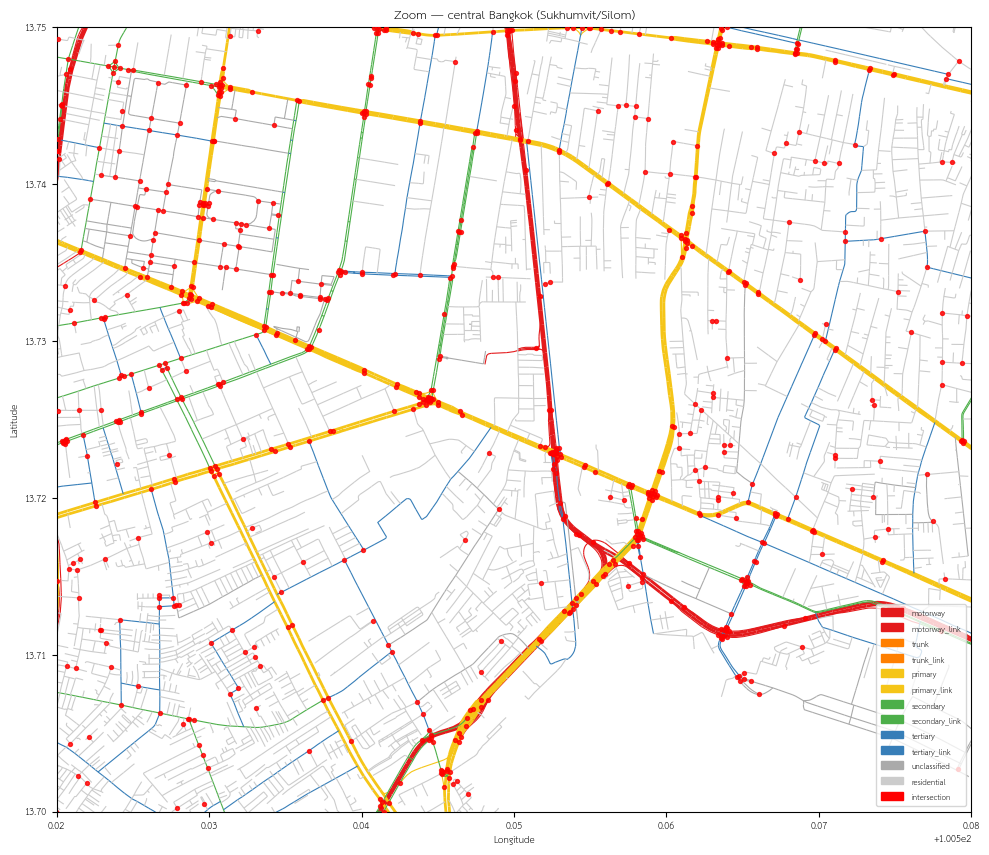

Segments in view     : 6,861
Intersections in view: 733


In [6]:
# --- Zoom into central Bangkok (Sukhumvit / Silom area) ---
ZOOM = (100.52, 13.70, 100.58, 13.75)  # minx, miny, maxx, maxy

segs_zoom = segs_wgs.cx[ZOOM[0]:ZOOM[2], ZOOM[1]:ZOOM[3]]
ints_zoom = ints_wgs.cx[ZOOM[0]:ZOOM[2], ZOOM[1]:ZOOM[3]]

fig, ax = plt.subplots(figsize=(10, 10))

for hw, color in HIGHWAY_COLORS.items():
    sub = segs_zoom[segs_zoom["highway"] == hw]
    if len(sub):
        lw = 2.0 if hw in ("motorway","trunk","primary") else 0.8
        sub.plot(ax=ax, color=color, linewidth=lw)

ints_zoom.plot(ax=ax, color="red", markersize=8, alpha=0.8,
               zorder=5, label="intersection")

ax.legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.8)
ax.set_xlim(ZOOM[0], ZOOM[2])
ax.set_ylim(ZOOM[1], ZOOM[3])
ax.set_title("Zoom — central Bangkok (Sukhumvit/Silom)", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

print(f"Segments in view     : {len(segs_zoom):,}")
print(f"Intersections in view: {len(ints_zoom):,}")